# Credit Card Fraud Detection using Machine Learning

This project focuses on detecting fraudulent credit card transactions. Given the highly imbalanced nature of fraud datasets, we will employ advanced techniques like **SMOTE** (Synthetic Minority Over-sampling Technique) and powerful models like **XGBoost** to achieve high detection rates while minimizing false positives.

## 1. Introduction to the Dataset
The dataset contains transactions made by credit cards in September 2013 by European cardholders. It presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.
You can download it from [Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).


## 2. Environment Setup
Run this cell to install required libraries if you are running this on Google Colab.


In [15]:
!pip install -q xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn


## 3. Importing Libraries


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')


## 4. Loading the Data
Upload the `creditcard.csv` file to your Colab environment or place it in the same directory as this notebook.


In [17]:
# Load the dataset
try:
    data = pd.read_csv('creditcard.csv')

    # Fix: Clean dataset immediately upon loading
    data.dropna(inplace=True)

    print('Dataset loaded successfully!')
except FileNotFoundError:
    print('Error: creditcard.csv not found. Please upload it to your Colab environment.')

# Display the first few rows
if 'data' in locals():
    display(data.head())


Dataset loaded successfully!


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 5. Exploratory Data Analysis (EDA)


In [18]:
if 'data' in locals():
    # Check the shape and basic statistics
    print('Dataset Shape:', data.shape)
    print('\nBasic Statistics:')
    display(data.describe())


Dataset Shape: (284807, 31)

Basic Statistics:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [19]:
if 'data' in locals():
    # Check for missing values
    print('Missing Values:\n', data.isnull().sum().max())


Missing Values:
 0


Outlier Fraction: 0.0017304750013189597
Fraud Cases: 492
Valid Transactions: 284315


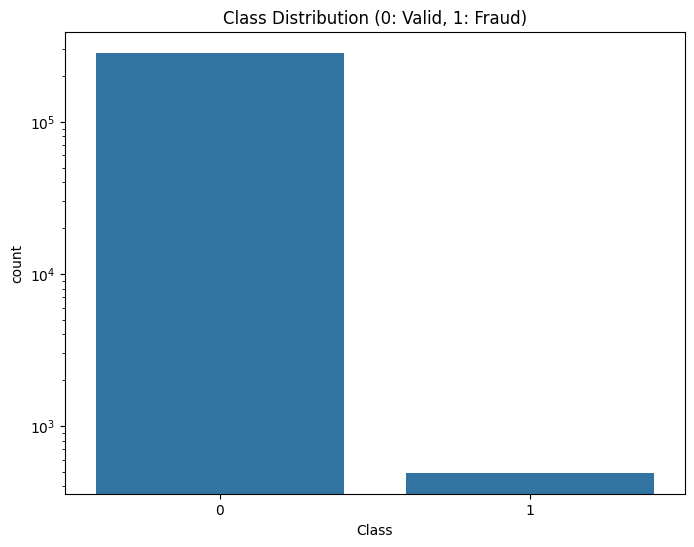

In [20]:
if 'data' in locals():
    # Analyzing Class Distribution
    fraud = data[data['Class'] == 1]
    valid = data[data['Class'] == 0]
    outlier_fraction = len(fraud) / float(len(valid))

    print(f'Outlier Fraction: {outlier_fraction}')
    print(f'Fraud Cases: {len(fraud)}')
    print(f'Valid Transactions: {len(valid)}')

    # Visualize Class Distribution
    plt.figure(figsize=(8, 6))
    sns.countplot(x='Class', data=data)
    plt.title('Class Distribution (0: Valid, 1: Fraud)')
    plt.yscale('log')
    plt.show()


In [21]:
if 'data' in locals():
    # Transaction Amount Details for Fraud vs Valid
    print('Amount details of the fraudulent transactions:')
    print(fraud['Amount'].describe())
    print('\nAmount details of valid transactions:')
    print(valid['Amount'].describe())


Amount details of the fraudulent transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Amount details of valid transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


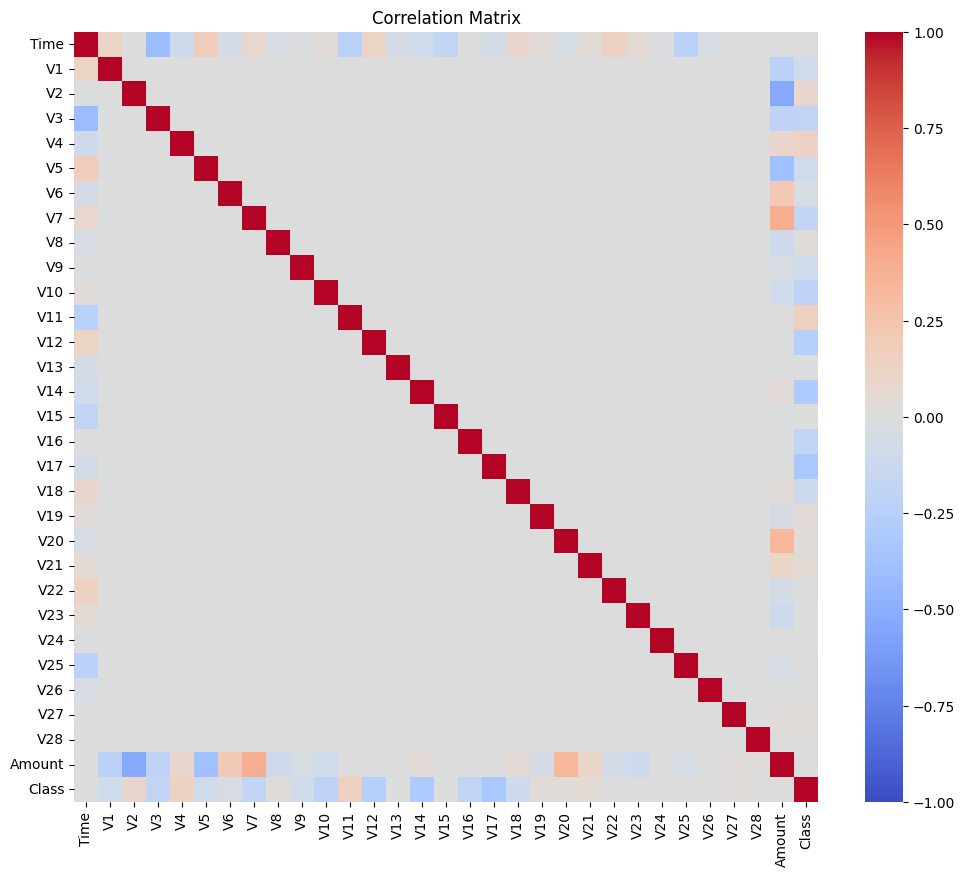

In [22]:
if 'data' in locals():
    # Correlation Matrix
    plt.figure(figsize=(12, 10))
    corr_matrix = data.corr()
    sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation Matrix')
    plt.show()


## 6. Data Preprocessing
The `V1` to `V28` features are already PCA transformed. However, `Time` and `Amount` have not been scaled. We will use `RobustScaler` as it is less prone to outliers.


In [23]:
if 'data' in locals():
    rob_scaler = RobustScaler()

    data['scaled_amount'] = rob_scaler.fit_transform(data['Amount'].values.reshape(-1,1))
    data['scaled_time'] = rob_scaler.fit_transform(data['Time'].values.reshape(-1,1))

    data.drop(['Time','Amount'], axis=1, inplace=True)

    # Move scaled columns to the front for better visibility
    scaled_amount = data['scaled_amount']
    scaled_time = data['scaled_time']
    data.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
    data.insert(0, 'scaled_amount', scaled_amount)
    data.insert(1, 'scaled_time', scaled_time)

    display(data.head())


,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## 7. Train-Test Split
We split the data before applying SMOTE to ensure no data leakage occurs from the test set into the training set.


In [24]:
if 'data' in locals():
    X = data.drop('Class', axis=1)
    y = data['Class']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print('Training set shape:', X_train.shape, y_train.shape)
    print('Testing set shape:', X_test.shape, y_test.shape)


Training set shape: (227845, 30) (227845,)
Testing set shape: (56962, 30) (56962,)


## 8. Handling Imbalanced Data with SMOTE
SMOTE creates synthetic samples of the minority class (fraud) to balance the dataset. This helps the model learn the patterns of fraud better instead of just predicting 'Valid' every time.


In [25]:
if 'data' in locals():
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    print('After SMOTE, Training set shape:', X_train_smote.shape, y_train_smote.shape)
    print('Class distribution after SMOTE:\n', y_train_smote.value_counts())


After SMOTE, Training set shape: (454902, 30) (454902,)
Class distribution after SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64


## 9. Model Building and Training
We will train an XGBoost Classifier, which is state-of-the-art for tabular data classification.


In [26]:
if 'data' in locals():
    # Initialize XGBoost model
    xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

    # Train the model on the SMOTE balanced data
    xgb_model.fit(X_train_smote, y_train_smote)
    print('XGBoost Model Trained Successfully!')


XGBoost Model Trained Successfully!


## 10. Model Evaluation
For imbalanced datasets, Accuracy is misleading. We focus on Precision, Recall, F1-Score, and the Matthews Correlation Coefficient (MCC).


--- XGBoost (with SMOTE) Evaluation ---
Accuracy  : 0.9992
Precision : 0.7179
Recall    : 0.8571
F1-Score  : 0.7814
MCC       : 0.7841

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.86      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



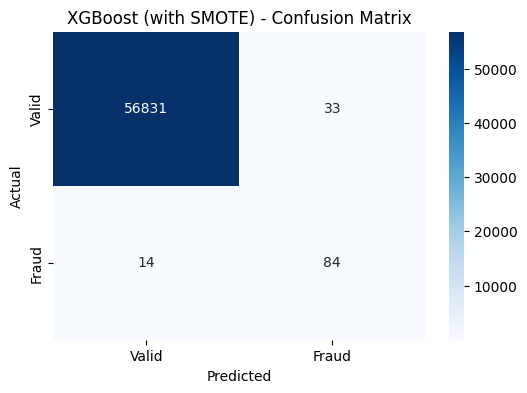

In [27]:
if 'data' in locals():
    def evaluate_model(model, X_test, y_test, model_name='Model'):
        y_pred = model.predict(X_test)

        print(f'--- {model_name} Evaluation ---')
        print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
        print(f'Precision : {precision_score(y_test, y_pred):.4f}')
        print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
        print(f'F1-Score  : {f1_score(y_test, y_pred):.4f}')
        print(f'MCC       : {matthews_corrcoef(y_test, y_pred):.4f}')
        print('\nClassification Report:\n', classification_report(y_test, y_pred))

        # Confusion Matrix
        plt.figure(figsize=(6, 4))
        conf_matrix = confusion_matrix(y_test, y_pred)
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Valid', 'Fraud'], yticklabels=['Valid', 'Fraud'])
        plt.title(f'{model_name} - Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()

    evaluate_model(xgb_model, X_test, y_test, 'XGBoost (with SMOTE)')


## 11. Comparison with Baseline (Random Forest without SMOTE)
Let's see how a standard Random Forest performs without balancing the data, just to see the improvement.


--- Random Forest (Baseline) Evaluation ---
Accuracy  : 0.9996
Precision : 0.9405
Recall    : 0.8061
F1-Score  : 0.8681
MCC       : 0.8705

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.81      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.90      0.93     56962
weighted avg       1.00      1.00      1.00     56962



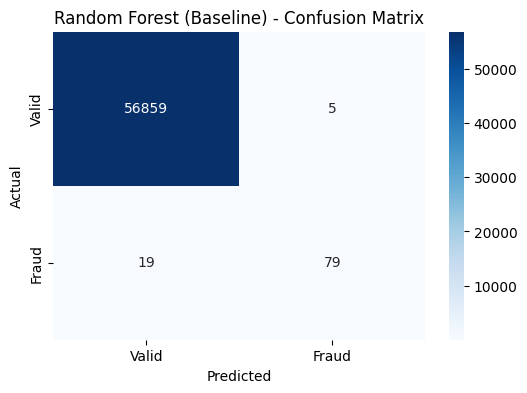

In [28]:
if 'data' in locals():
    rf_baseline = RandomForestClassifier(random_state=42)
    rf_baseline.fit(X_train, y_train) # Training on original imbalanced data
    evaluate_model(rf_baseline, X_test, y_test, 'Random Forest (Baseline)')


## Conclusion
The XGBoost model trained with SMOTE data generally shows an excellent balance of Precision and Recall, proving to be a highly effective approach for Credit Card Fraud Detection. The high MCC score further solidifies its reliability on this imbalanced dataset.
